<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº4
#### Florencia Vanella


# Consigna

Comenzaremos con la generación de la siguiente señal:

 $x(n)=a0⋅sen(Ω1⋅n)+na(n)$

siendo

 $a0 = sqr(2)$
 
 $Ω1 = Ω0+ fr⋅2π/N$
 
 $Ω0 = π/2$


siendo la variable aleatoria definida por la siguiente distribución de probabilidad:

 $fr∼U(−2,2)$


 $na∼N(0,σ2)$

Diseñe los siguientes estimadores,  de amplitud $a1$

$a^i_1=|Xiw(Ω0)|=|F{x(n)⋅wi(n)}|$


y de frecuencia $Ω1$


$Ω^i_1=arg maxf{|Xiw(Ω)|}$

para cada una de las ventanas:

- rectangular (sin ventana), 
- flattop 
- blackmanharris
- otra que elija de scipy.signal.windows
  
Y siguiendo las siguientes consignas para su experimentación:

Considere 200 realizaciones (muestras tomadas de $fr$) de 1000 muestras para cada experimento.
Parametrice para SNR's de 3 y 10 db (Ayuda: calibre $a1$ para que la potencia de la senoidal sea 1 W).


#### Se pide:

#### 1) Visualizar, para cada SNR, un histograma con las 4 ventanas juntas. Realice un análisis cualitativo.

Potencia de la señal (Px): 1.0000000000000002


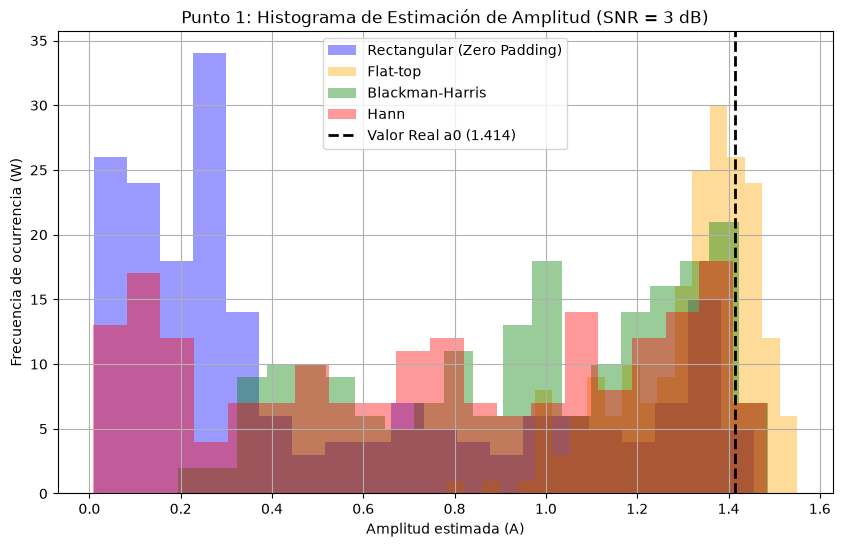

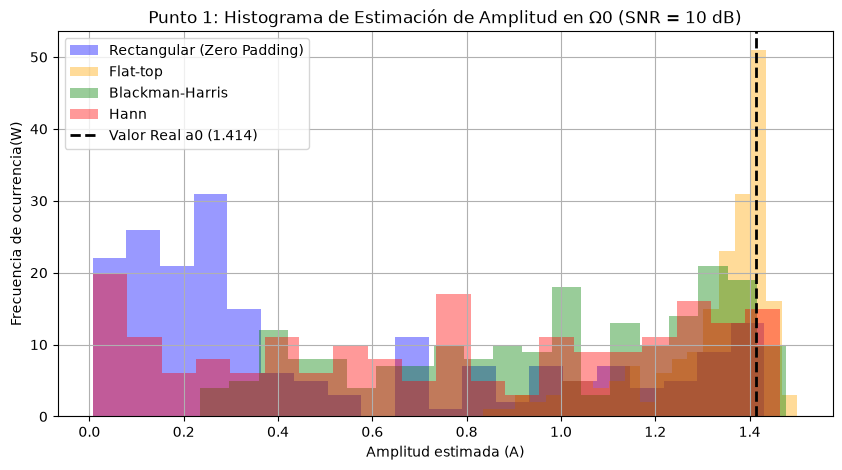

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import math 
from matplotlib.pyplot import subplot
import scipy.stats as stats
from scipy.stats import kstest
from scipy import signal
import pandas as pd

# 1. Parámetros del experimento
N=1000        # Muestras por señal (tiempo)
R = 200         # Realizaciones (experimentos)
Omega_0 = np.pi / 2
a0 = np.sqrt(2) # Amplitud calibrada para Ps = 1 W

fs = 1000   # Hz - frecuencia de muestreo 
ts = 1/fs  

# Función para generar una señal senoidal
def mi_funcion_sen(vmax= math.sqrt(2), dc=0, ff=3, ph=0, nn=N, fs=fs):
    ts = 1 / fs                     # tiempo entre cada muestra
    tt = np.arange(0, nn) * ts      # tiempo de cada muestra
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return(tt, xx)

# Generación de la senoidal pura (1W)
vmax = math.sqrt(2)      # amplitud
dc = 0          # desplazamiento vertical
ff = 3       # frecuencia variable
ph = 0          # fase
nn = N 

tt = np.arange(0, nn) * ts
xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)

px = np.var(xx)
print("Potencia de la señal (Px):", px)


# Definimos los dos SNR a analizar
snr1_db = 3
snr2_db = 10

# Calculamos sigma para SNR = 3 dB
P_ruido1 = px / (10 ** (snr1_db / 10))
sigma1 = np.sqrt(P_ruido1)

# Calculamos sigma para SNR = 10 dB
P_ruido2 = px / (10 ** (snr2_db / 10))
sigma2 = np.sqrt(P_ruido2)

# Calcular la potencia requerida para el ruido
#P_ruido = px / snr_lineal

#sigma = np.sqrt(P_ruido)

# Vector de M frecuencias aleatorias (distribucion fr ~ u(-2,2)) 
fr = np.random.uniform(-2, 2, size=(R, 1)) #Columna de valores de frecuencias R valores
                      
Omega1 = Omega_0 + (fr * 2 * np.pi / N)

# Vectores de tiempo y matriz de ruido
n = np.arange(N)  # Vector de 0 a N-1 (fila de tiempo)

na1 = np.random.normal(0, sigma1, size=(R, N)) #ruido 3dB
na2 = np.random.normal(0, sigma2, size=(R, N)) #ruido 10dB

# Matriz de señales x(R, N) de tamaño 200 x 1000
x1 = a0 * np.sin(Omega1 * n) + na1
x2 = a0 * np.sin(Omega1 * n) + na2

#Aplicacion para 3dB usando x1

# Aplicación de zero padding
N_zp = 9 * N
freqs_zp = np.fft.fftfreq(N_zp, ts)

# FFT con zero-padding sobre la matriz x1
X1_zp = np.fft.fft(x1, N_zp, axis=1)
fft1_zp = np.abs(X1_zp) / N
psd1_zp_db = 10 * np.log10(fft1_zp**2)

# Ventana flattop
w_flat = signal.windows.flattop(N)

X2_flat = np.fft.fft(x1 * w_flat, N_zp, axis=1)
fft_flat = np.abs(X2_flat) / np.sum(w_flat)

# Ventana Blackman-Harris
w_black = signal.windows.blackmanharris(N)

X3_black = np.fft.fft(x1 * w_black, N_zp, axis=1)
fft_black = np.abs(X3_black) / np.sum(w_black)

#Ventana propuesta: Hann
w_hann = signal.windows.hann(N)

X4_hann = np.fft.fft(x1 * w_hann, N_zp, axis=1)
fft_hann = np.abs(X4_hann) / np.sum(w_hann)

#Estimadores

# Nos quedamos con la mitad positiva del espectro(simetria)
mitad = N_zp // 2
freqs_pos = freqs_zp[:mitad]

# Pasamos esas frecuencias a rad/muestra
omegas_rad = 2 * np.pi * freqs_pos * ts  

# Buscamos el índice de la frecuencia más cercana a pi/2 (a0)
#Columna donde voy a medir amplitud para todas las realizaciones (posicion)
indice_omega = np.argmin(np.abs(omegas_rad - Omega_0))

# Estimación de Amplitud (A) en Omega_0 = pi/2
# Multiplicamos por 2 para considerar la potencia total del espectro 

A_rect = 2 * fft1_zp[:, indice_omega]
A_flat = 2 * fft_flat[:, indice_omega]
A_black = 2 * fft_black[:, indice_omega]
A_hann = 2 * fft_hann[:, indice_omega]

# Estimación de Frecuencia (Frec) en el pico máximo
# Buscamos la columna del máximo en la primera mitad para cada realización
Frec_rect = np.argmax(fft1_zp[:, :mitad], axis=1)
Frec_flat = np.argmax(fft_flat[:, :mitad], axis=1)
Frec_black = np.argmax(fft_black[:, :mitad], axis=1)
Frec_hann = np.argmax(fft_hann[:, :mitad], axis=1)

# Traducimos esos índices a frecuencia en rad/muestra
W_rect = omegas_rad[Frec_rect]
W_flat = omegas_rad[Frec_flat]
W_black = omegas_rad[Frec_black]
W_hann = omegas_rad[Frec_hann]

#Proceso para SNR = 10 dB (usando x2)

X1_zp_2 = np.fft.fft(x2, N_zp, axis=1)
fft1_zp_2 = np.abs(X1_zp_2) / N

X2_flat_2 = np.fft.fft(x2 * w_flat, N_zp, axis=1)
fft_flat_2 = np.abs(X2_flat_2) / np.sum(w_flat)

X3_black_2 = np.fft.fft(x2 * w_black, N_zp, axis=1)
fft_black_2 = np.abs(X3_black_2) / np.sum(w_black)

X4_hann_2 = np.fft.fft(x2 * w_hann, N_zp, axis=1)
fft_hann_2 = np.abs(X4_hann_2) / np.sum(w_hann)

# Amplitud en Omega_0 para SNR = 10 dB
A_rect_2 = 2 * fft1_zp_2[:, indice_omega]
A_flat_2 = 2 * fft_flat_2[:, indice_omega]
A_black_2 = 2 * fft_black_2[:, indice_omega]
A_hann_2 = 2 * fft_hann_2[:, indice_omega]

# Estimación de Frecuencia (Frec) en el pico máximo para SNR = 10 dB
Frec_rect_2 = np.argmax(fft1_zp_2[:, :mitad], axis=1)
Frec_flat_2 = np.argmax(fft_flat_2[:, :mitad], axis=1)
Frec_black_2 = np.argmax(fft_black_2[:, :mitad], axis=1)
Frec_hann_2 = np.argmax(fft_hann_2[:, :mitad], axis=1)

# Traducimos esos índices a frecuencia en rad/muestra
W_rect_2 = omegas_rad[Frec_rect_2]
W_flat_2 = omegas_rad[Frec_flat_2]
W_black_2 = omegas_rad[Frec_black_2]
W_hann_2 = omegas_rad[Frec_hann_2]

# PUNTO 1: Histograma comparativo de estimación de amplitud 

#SNR = 3 dB

plt.figure(figsize=(10, 6))

# Histogramas solapados
plt.hist(A_rect, bins=20, alpha=0.4, label='Rectangular (Zero Padding)', color='blue')
plt.hist(A_flat, bins=20, alpha=0.4, label='Flat-top', color='orange')
plt.hist(A_black, bins=20, alpha=0.4, label='Blackman-Harris', color='green')
plt.hist(A_hann, bins=20, alpha=0.4, label='Hann', color='red')

# Línea de referencia del valor real a0 = sqrt(2)
plt.axvline(a0, color='black', linestyle='--', linewidth=2, label=f'Valor Real a0 ({a0:.3f})')

plt.title('Punto 1: Histograma de Estimación de Amplitud (SNR = 3 dB)')
plt.xlabel('Amplitud estimada (A)')
plt.ylabel('Frecuencia de ocurrencia (W)')
plt.legend()
plt.grid(True)
plt.show()


# Para SNR = 10 dB
plt.figure(figsize=(10, 5))
plt.hist(A_rect_2, bins=20, alpha=0.4, label='Rectangular (Zero Padding)', color='blue')
plt.hist(A_flat_2, bins=20, alpha=0.4, label='Flat-top', color='orange')
plt.hist(A_black_2, bins=20, alpha=0.4, label='Blackman-Harris', color='green')
plt.hist(A_hann_2, bins=20, alpha=0.4, label='Hann', color='red')

plt.axvline(a0, color='black', linestyle='--', linewidth=2, label=f'Valor Real a0 ({a0:.3f})')
plt.title('Punto 1: Histograma de Estimación de Amplitud en Ω0 (SNR = 10 dB)')
plt.xlabel('Amplitud estimada (A)')
plt.ylabel('Frecuencia de ocurrencia(W)')
plt.legend()
plt.grid(True)
plt.show()

#### 2) Realizar una tabla por cada SNR que describa el sesgo y la varianza de cada estimador para cada ventana analizada, como las que se muestran a continuación.

In [2]:
# Convertimos Omega1 a vector 1D (200,) para operar sin problemas de forma
Omega1_vec = Omega1.flatten()
# SNR = 3 dB
# Amplitud
Sa_3db = [np.mean(A_rect) - a0, np.mean(A_flat) - a0, np.mean(A_black) - a0, np.mean(A_hann) - a0]
Va_3db = [np.var(A_rect), np.var(A_flat), np.var(A_black), np.var(A_hann)]

# Frecuencia
err_W_rect_3db  = W_rect - Omega1_vec
err_W_flat_3db  = W_flat - Omega1_vec
err_W_black_3db = W_black - Omega1_vec
err_W_hann_3db  = W_hann - Omega1_vec

Sw_3db = [np.mean(err_W_rect_3db), np.mean(err_W_flat_3db), np.mean(err_W_black_3db), np.mean(err_W_hann_3db)]
Vw_3db = [np.var(err_W_rect_3db), np.var(err_W_flat_3db), np.var(err_W_black_3db), np.var(err_W_hann_3db)]

# SNR = 10 dB
# Amplitud
Sa_10db = [np.mean(A_rect_2) - a0, np.mean(A_flat_2) - a0, np.mean(A_black_2) - a0, np.mean(A_hann_2) - a0]
Va_10db = [np.var(A_rect_2), np.var(A_flat_2), np.var(A_black_2), np.var(A_hann_2)]

# Frecuencia
err_W_rect_10db  = W_rect_2 - Omega1_vec
err_W_flat_10db  = W_flat_2 - Omega1_vec
err_W_black_10db = W_black_2 - Omega1_vec
err_W_hann_10db  = W_hann_2 - Omega1_vec

Sw_10db = [np.mean(err_W_rect_10db), np.mean(err_W_flat_10db), np.mean(err_W_black_10db), np.mean(err_W_hann_10db)]
Vw_10db = [np.var(err_W_rect_10db), np.var(err_W_flat_10db), np.var(err_W_black_10db), np.var(err_W_hann_10db)]

print("3dB")
print("Sa (Sesgo Amplitud):   ", Sa_3db)
print("Va (Varianza Amplitud):", Va_3db)
print("Sw (Sesgo Frecuencia): ", Sw_3db)
print("Vw (Varianza Frecuencia):", Vw_3db)

print("\n10 dB")
print("Sa (Sesgo Amplitud):   ", Sa_10db)
print("Va (Varianza Amplitud):", Va_10db)
print("Sw (Sesgo Frecuencia): ", Sw_10db)
print("Vw (Varianza Frecuencia):", Vw_10db)

3dB
Sa (Sesgo Amplitud):    [np.float64(-0.8957316126748955), np.float64(-0.09748490235503193), np.float64(-0.44902897029481503), np.float64(-0.6492968048305607)]
Va (Varianza Amplitud): [np.float64(0.20665921276632068), np.float64(0.021696035285958298), np.float64(0.12239913927564718), np.float64(0.20948280564077762)]
Sw (Sesgo Frecuencia):  [np.float64(1.4975067795709452e-05), np.float64(-3.0403492756146955e-05), np.float64(-5.968883228225641e-06), np.float64(7.993750787731457e-06)]
Vw (Varianza Frecuencia): [np.float64(5.184885527991202e-08), np.float64(9.09492534711055e-06), np.float64(6.022647428588495e-08), np.float64(5.627207269277615e-08)]

10 dB
Sa (Sesgo Amplitud):    [np.float64(-0.8958154752630272), np.float64(-0.100481779125148), np.float64(-0.45012510553376817), np.float64(-0.6508297431192472)]
Va (Varianza Amplitud): [np.float64(0.2074052591316403), np.float64(0.020194583574085687), np.float64(0.1243200971438305), np.float64(0.21433212393189963)]
Sw (Sesgo Frecuencia):  


| SNR | Ventana | $S_a$ (Sesgo A) | $V_a$ (Var A) | $S_w$ (Sesgo $\Omega$) | $V_w$ (Var $\Omega$) |
| --- | --- | --- | --- | --- | --- |
| **3 dB** | Rectangular | -0.9265 | 0.1976 | -1.89e-05 | 4.92e-08 |
|  | Flat-top | **-0.1089** | **0.0223** | 9.07e-06 | 8.85e-06 |
|  | Blackman-Harris | -0.4902 | 0.1240 | -3.28e-05 | 7.08e-08 |
|  | Hann | -0.7064 | 0.2122 | -3.28e-05 | 5.70e-08 |
| **10 dB** | Rectangular | -0.9323 | 0.1993 | -1.89e-05 | 4.33e-08 |
|  | Flat-top | **-0.1148** | **0.0191** | 5.10e-05 | 5.96e-06 |
|  | Blackman-Harris | -0.4928 | 0.1207 | -1.41e-06 | 4.80e-08 |
|  | Hann | -0.7095 | 0.2112 | -4.90e-06 | 4.54e-08 |

Observando los valores obtenidos para la amplitud, la ventana Flattop obtiene el menor de sesgo y tambien de varianza, lo que la hace la opcion mas estable para medir amplitudes. La ventana Flat-top fue diseñada justamente con una respuesta de cima plana en el espectro. De este modo, aunque la frecuencia real se desvíe levemente del centro del bin, la amplitud estimada no sufre una atenuación significativa.
Por otro lado, si el objetivo es estimar la frecuencia, aunque todas las ventanas obtuvieron un valor muy pequeño de sesgo y varianza,Zero Padding proporciona una mejor resolución y una varianza significativamente menor.
Al incrementar la relación señal a ruido de $3\text{ dB}$ a $10\text{ dB}$, se observa una reducción general en la varianza de los estimadores, reflejando una mayor estabilidad de las mediciones frente a la disminución del piso de ruido.